In [1]:
import matplotlib.pyplot as plt
import numpy as np
import sys
import os
import h5py
import matplotlib.colors as colors
import matplotlib.cm

#####Import Ollie Tools
dirPath = "C:/Coding"
sys.path.insert(0, dirPath)
import OllieTools as oj
print(dirPath)


####Import Ollie Tools MAC
# dirPath = "/Users/olliejackson/Coding"
# sys.path.insert(0, dirPath)
# import OllieTools as oj
# print(dirPath)

oj.thesis_plot_settings()

C:/Coding/Code
C:/Coding
Thesis plot settings applied


	 - 0D0 : <HDF5 group "/0D0" (1 members)>
		 - U100 : <HDF5 group "/0D0/U100" (1 members)>
			 - L100 : <HDF5 group "/0D0/U100/L100" (2 members)>
				 - RPM0 : <HDF5 dataset "RPM0": shape (2999, 149, 239, 2), type "<f8">
				 - RPM12 : <HDF5 dataset "RPM12": shape (2999, 149, 239, 2), type "<f8">


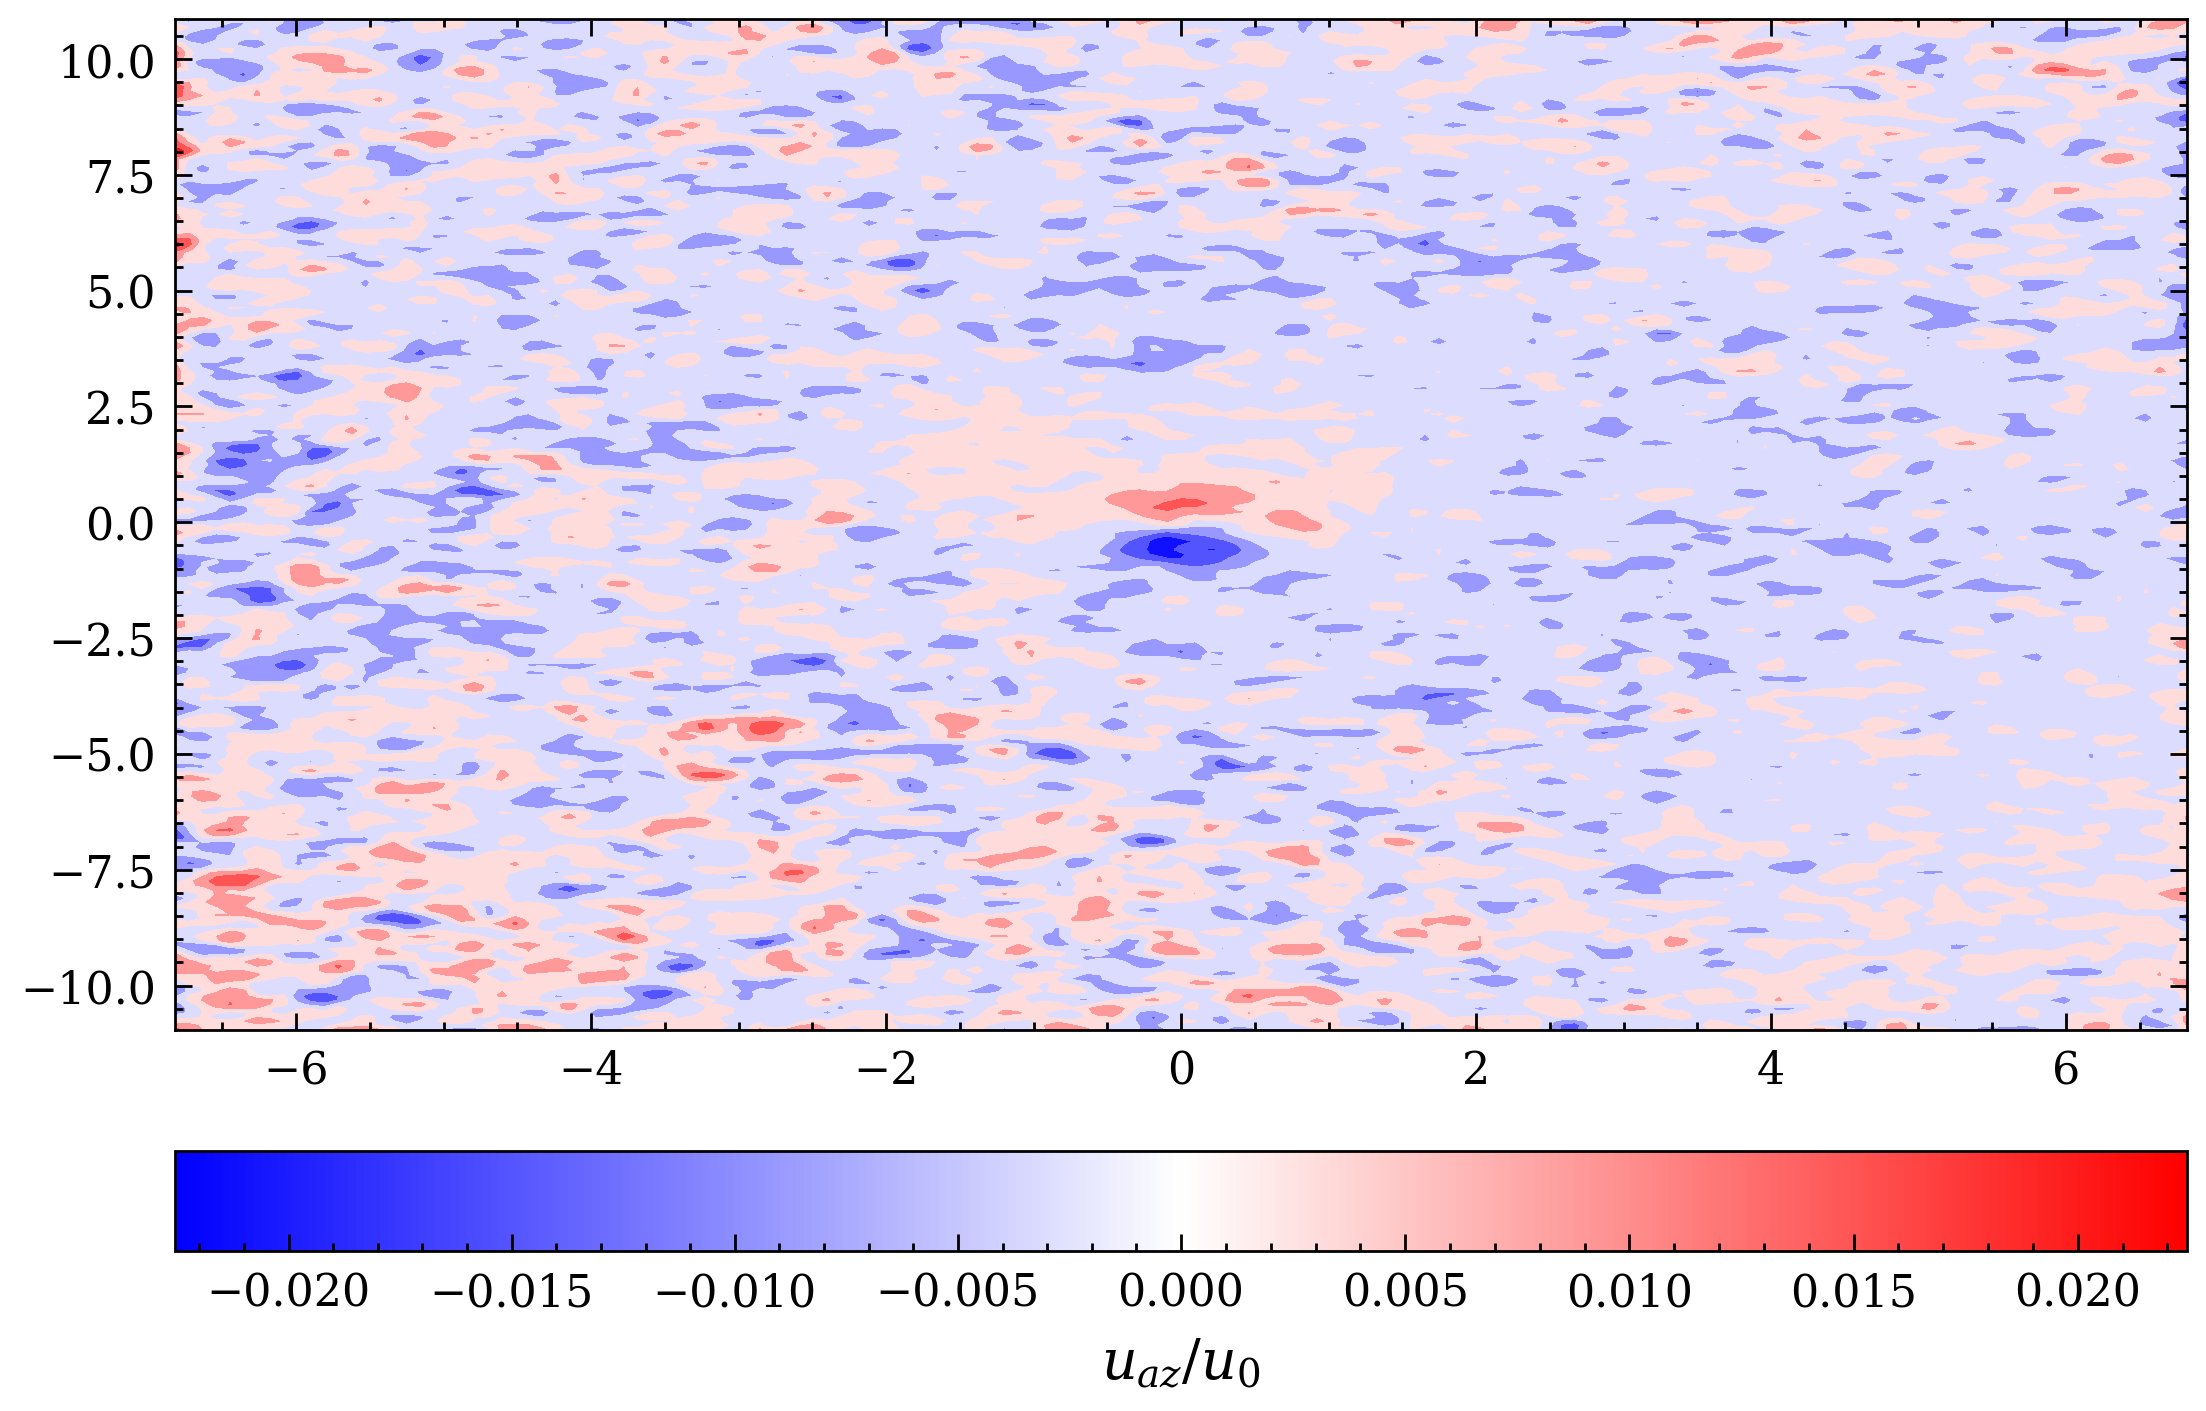

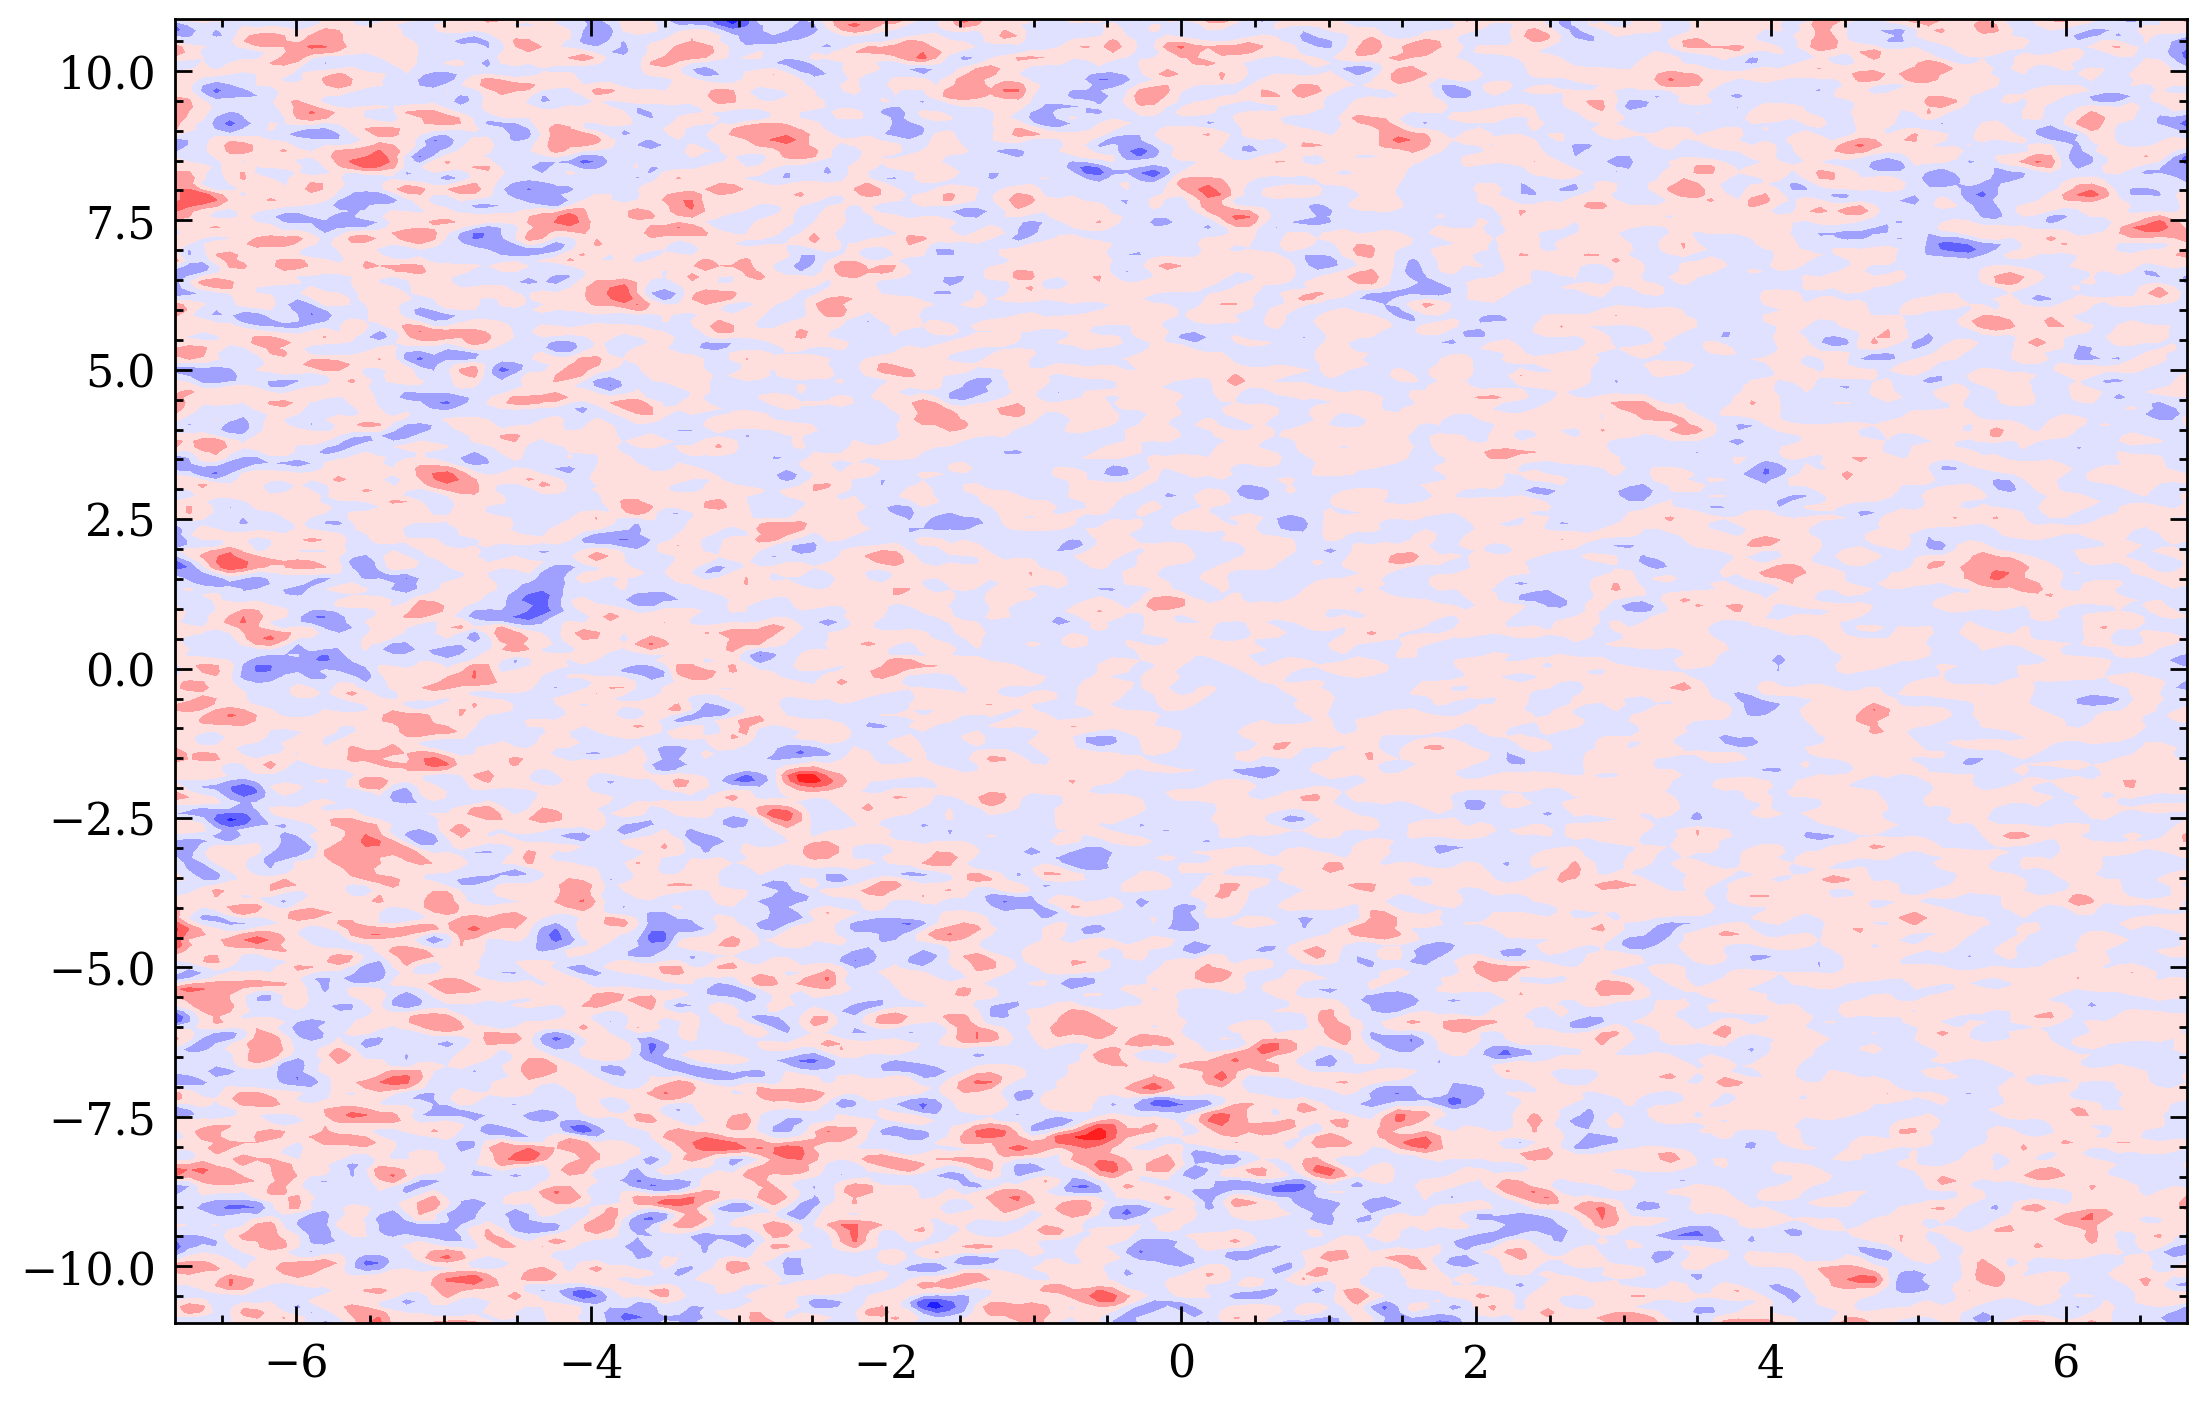

In [17]:
h5file = h5py.File('E:/H5/0D0HLSFine.h5', 'r')
oj.descend_obj(h5file)
index = 0
rpms = [0, 12]

times = [5, 7, 15]
frames0 = [750, 1020, 1470]
frames2 = [840, 1125, 2295]
frames12 = [750, 1080, 2295]

vels = h5file['0D0']['U100']['L100']['RPM0']
u = vels[:,:,:,0]
v = vels[:,:,:,1]
r_nd, z_nd = oj.NDUnitsForPlotsHoriz(u.shape[1], u.shape[2])

x = np.linspace(0 , u.shape[2], u.shape[2])
y = np.linspace(0 , u.shape[1], u.shape[1])


U_azMean = np.zeros((u.shape[0], u.shape[1], u.shape[2]))
for i in range(u.shape[0]):
    r, theta, U_r,  U_az, x0, y0 = oj.ConvertCylindrical(120, 75, x, y, u[i,:,:], v[i,:,:])
    U_azMean[i,:,:] = U_az
U_azMean = np.mean(U_azMean, axis = 0)

norm = colors.TwoSlopeNorm(vmin=np.min(U_azMean), vcenter=0, vmax=np.max(U_azMean))
f1, ax1 = plt.subplots(1, 1, sharex=True, sharey=True, figsize=(5.5, 3.5), dpi = 400)
ax1.contourf(r_nd, -z_nd, np.rot90(U_azMean[:,:],3), cmap = 'bwr', norm = norm)
f1.colorbar(matplotlib.cm.ScalarMappable(norm=norm, cmap='bwr'), ax=ax1, label=r'$u_{az}/u_{0}$', location='bottom')

r, theta, U_r, U_az, x0, y0 = oj.ConvertCylindrical(120, 75, x, y, u[2000,:,:], v[2000,:,:])
f2, ax2 = plt.subplots(1, 1, sharex=True, sharey=True, figsize=(5.5, 3.5), dpi = 400)
ax2.contourf(r_nd, -z_nd, np.rot90(U_az[:,:],3), cmap = 'bwr')